In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = "landmarks_unnormalised_with_angles_clean.csv"  # change path if needed
df = pd.read_csv(CSV_PATH)
positions_order = sorted(df["Position"].unique(), key=lambda x: int(x[1:]))  # extracts the number part
df["Position"] = pd.Categorical(df["Position"], categories=positions_order, ordered=True)
df = df.sort_values("Position")

# df = df[df["Person"].str.contains("rob", na=False)]

# --- Clean / sanity check ---
print("Loaded data:", df.shape)
display(df.head())

summary = df.groupby("Position")[["shoulder_tilt_deg", "hip_tilt_deg",
                                  "shoulder_rotation_deg", "hip_rotation_deg"]].agg(
    ["mean", "std", "min", "max"]
)
summary

Loaded data: (143, 10)


,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg
0,0,eric_1_frame27.jpg,eric_1,FO,frame27,P1,8.462072,0.495341,15.049882,16.201505
14,14,tom_3_frame12.jpg,tom_3,FO,frame12,P1,7.505523,3.483993,15.477464,11.773180
13,13,tom_2_frame27.jpg,tom_2,FO,frame27,P1,9.379230,4.592826,1.798426,10.780642
12,12,tom_1_frame18.jpg,tom_1,FO,frame18,P1,4.585690,1.045696,17.979180,6.278109
11,11,rob_2_frame16.jpg,rob_2,FO,frame16,P1,5.177479,3.185149,18.036425,20.751786


C:\Users\cryst\AppData\Local\Temp\ipykernel_25096\2057038772.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("Position")[["shoulder_tilt_deg", "hip_tilt_deg",


shoulder_tilt_deg                                  hip_tilt_deg  \
                      mean        std        min        max         mean   
Position                                                                   
P1                7.560031   2.480809   3.522581  12.473958     2.996089   
P2               12.817276   5.221396   2.136919  22.553269     1.801085   
P3               17.626976  13.756393   1.969913  50.364664     5.183671   
P4                6.977490   8.080474   0.086231  29.120730     4.086528   
P5               11.205401   6.644354   4.305826  23.785963     4.715516   
P6                6.932438   3.649844   1.417763  14.404716     1.855877   
P7               16.578872   5.490082   5.330767  23.448541     3.648949   
P8               31.405460   6.156876  22.551401  42.741854     6.148073   
P9               31.309827  18.826230   6.953464  56.393023     6.801223   
P10              21.097800  18.781248   1.370940  63.454259    11.898014   

                                        shoulder_rotation_deg             \
               std       min        max                  mean        std   
Position                                                                   
P1        1.305258  0.495341   4.592826             10.072341   6.012775   
P2        1.823542  0.029654   6.616914             55.944253   8.146835   
P3        2.652608  2.452458  11.978996             71.719011   5.709761   
P4        2.522112  0.785130  10.125650             73.625667   6.805982   
P5        1.322025  2.541546   7.547895             61.172948   7.965084   
P6        0.917977  0.226785   2.963675             44.131034  10.066654   
P7        1.376979  1.400996   6.342789             28.949235  16.531010   
P8        3.176858  1.517416  11.358766             62.478749  14.731866   
P9        5.128794  0.717659  16.132146             78.105426   8.112767   
P10       8.088317  0.652055  24.480011             84.743822   5.867214   

                               hip_rotation_deg                        \
                min        max             mean        std        min   
Position                                                                
P1         1.798426  19.000035        11.461219   6.315940   0.355066   
P2        41.586939  70.111747        26.647194  14.621600   2.661650   
P3        61.206229  80.278079        42.930524   9.997958  25.818089   
P4        55.685173  81.972035        55.153117  16.335870  32.099705   
P5        48.307815  79.170863        26.348236  11.275000   2.434097   
P6        18.470015  54.831056        23.595675   8.209310  12.037027   
P7         2.368221  52.445807        23.061800  13.998956   1.885800   
P8        16.444149  75.298487        53.541745  16.046210  11.311568   
P9        57.553339  86.057869        72.618029  11.827306  33.374057   
P10       70.584951  89.665113        85.284714   2.471666  81.110535   

                     
                max  
Position             
P1        21.986555  
P2        46.453333  
P3        61.288718  
P4        79.291569  
P5        57.228924  
P6        38.703382  
P7        42.651440  
P8        73.411498  
P9        80.427874  
P10       89.362223

In [38]:
# --- Load both datasets ---
df_coach = pd.read_csv("standard_angles.csv")

# --- Merge by Position (not Frame_Name) ---
df_compare = pd.merge(df, df_coach, on="Position", how="left")

# --- Compute differences per frame (Mediapipe - Coach) ---
for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    df_compare[f"{angle}_diff"] = df_compare[angle] - df_compare[f"{angle.replace("_deg", "_standard")}"]
    df_compare[f"{angle}_abs_diff"] = df_compare[f"{angle}_diff"].abs()

# --- Summary: Mean absolute difference per position ---
summary_diff = df_compare.groupby("Position")[[
    "shoulder_tilt_deg_abs_diff",
    "hip_tilt_deg_abs_diff",
    "shoulder_rotation_deg_abs_diff",
    "hip_rotation_deg_abs_diff"
]].mean().reset_index()

display(summary_diff)

,Position,shoulder_tilt_deg_abs_diff,hip_tilt_deg_abs_diff,shoulder_rotation_deg_abs_diff,hip_rotation_deg_abs_diff
0,P1,1.984449,2.063376,5.256008,7.974576
1,P10,16.560484,8.437662,53.256178,23.715286
2,P2,11.182724,2.650983,14.022552,14.528593
3,P3,20.446366,3.494462,5.977433,10.201736
4,P4,30.022510,5.063559,14.374333,16.531374
5,P5,21.794599,2.362755,6.743139,20.000508
6,P6,5.504783,6.144123,43.131034,9.623122
7,P7,13.421128,7.351051,14.025969,19.938200
8,P8,7.683991,5.851927,17.256934,11.104313
9,P9,18.110983,7.483063,9.478008,13.615092


In [39]:
# Flatten MultiIndex columns (mean/std/min/max)
summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
summary = summary.reset_index()

# Merge with coach standard angles
df_compare_summary = pd.merge(summary, df_coach, on="Position", how="left")

display(df_compare_summary.head())

,Position,shoulder_tilt_deg_mean,shoulder_tilt_deg_std,shoulder_tilt_deg_min,shoulder_tilt_deg_max,hip_tilt_deg_mean,hip_tilt_deg_std,hip_tilt_deg_min,hip_tilt_deg_max,shoulder_rotation_deg_mean,...,hip_rotation_deg_std,hip_rotation_deg_min,hip_rotation_deg_max,shoulder_tilt_standard,hip_tilt_standard,LR,shoulder_rotation_standard,hip_rotation_standard,OC,tilt_ca
0,P1,7.560031,2.480809,3.522581,12.473958,2.996089,1.305258,0.495341,4.592826,10.072341,...,6.315940,0.355066,21.986555,8,1,R,8,4,O,FO
1,P2,12.817276,5.221396,2.136919,22.553269,1.801085,1.823542,0.029654,6.616914,55.944253,...,14.621600,2.661650,46.453333,24,4,L,42,18,C,FO
2,P3,17.626976,13.756393,1.969913,50.364664,5.183671,2.652608,2.452458,11.978996,71.719011,...,9.997958,25.818089,61.288718,35,8,L,77,36,C,DTL
3,P4,6.977490,8.080474,0.086231,29.120730,4.086528,2.522112,0.785130,10.125650,73.625667,...,16.335870,32.099705,79.291569,37,9,L,88,44,C,DTL
4,P5,11.205401,6.644354,4.305826,23.785963,4.715516,1.322025,2.541546,7.547895,61.172948,...,11.275000,2.434097,57.228924,33,7,L,65,7,C,DTL


C:\Users\cryst\AppData\Local\Temp\ipykernel_25096\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


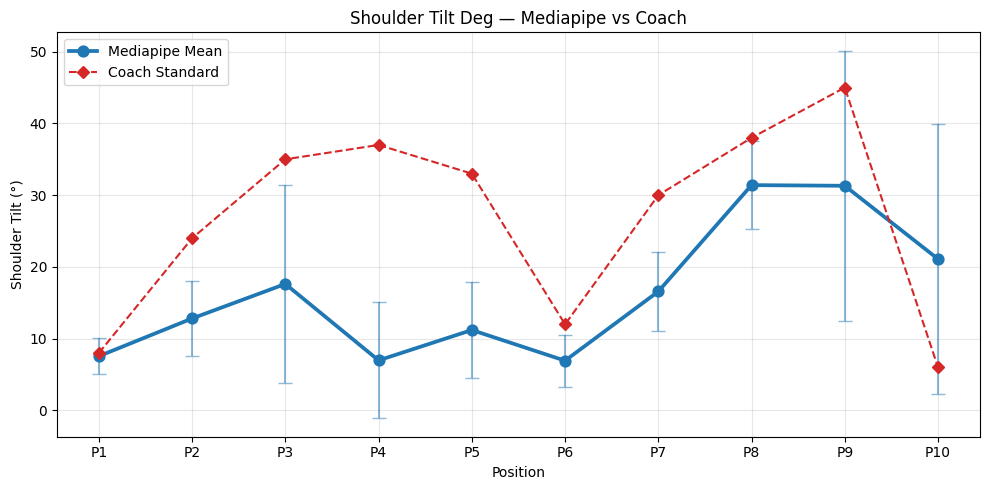

C:\Users\cryst\AppData\Local\Temp\ipykernel_25096\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


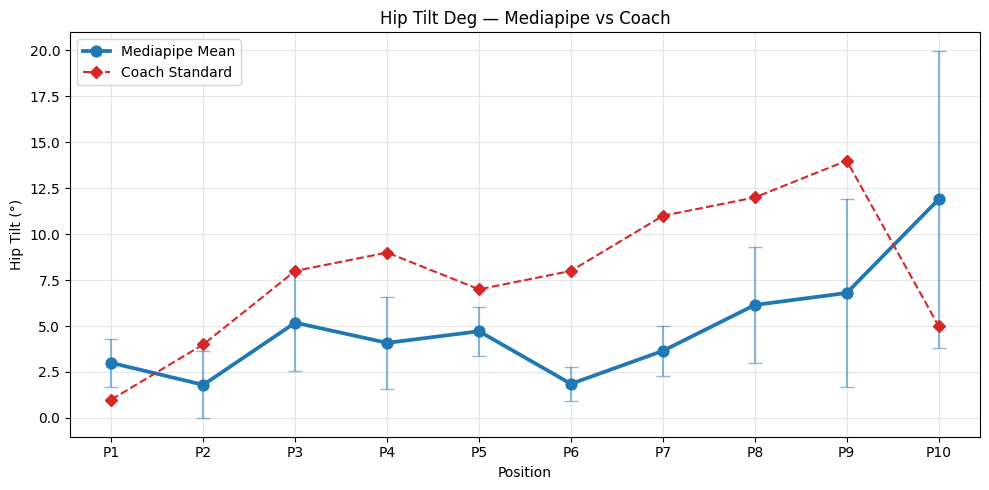

C:\Users\cryst\AppData\Local\Temp\ipykernel_25096\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


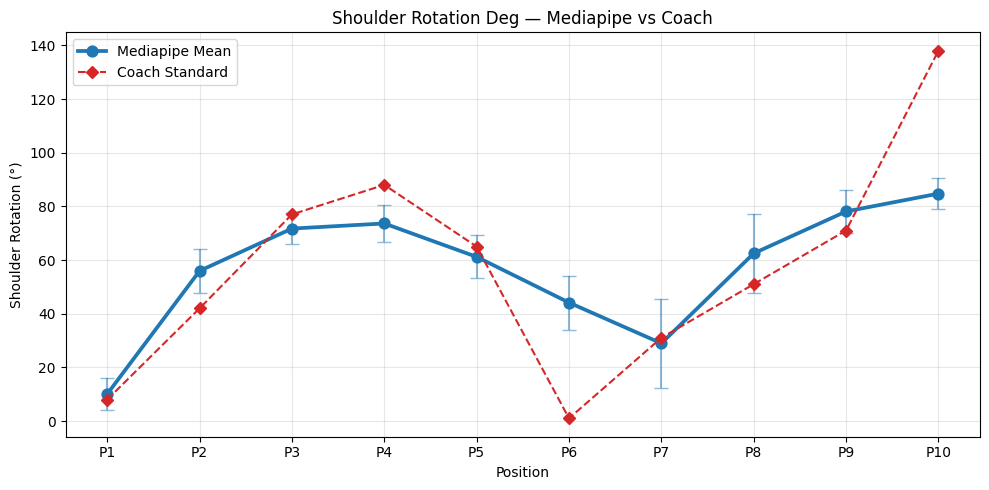

C:\Users\cryst\AppData\Local\Temp\ipykernel_25096\1593665105.py:7: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


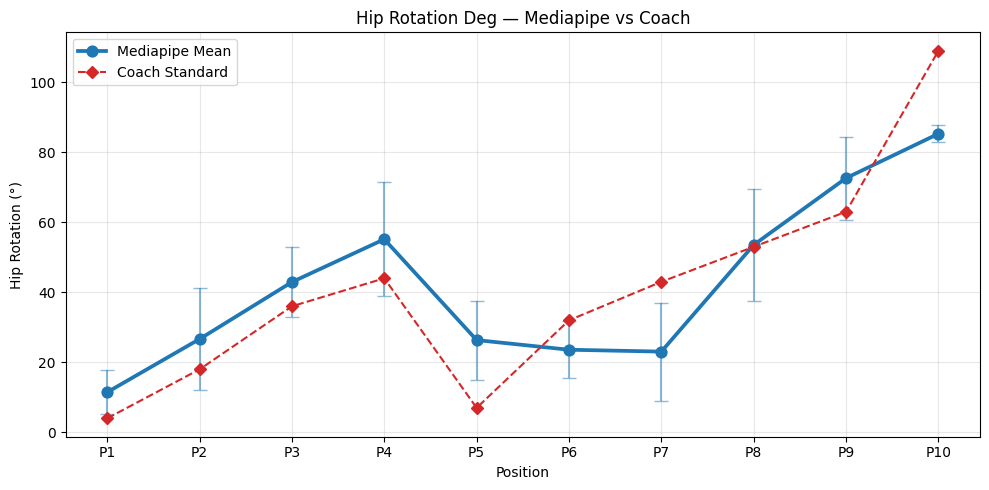

In [40]:
def plot_angle_comparison(angle_name, ylabel=None):
    mean_col = f"{angle_name}_mean"
    std_col = f"{angle_name}_std"
    coach_col = f"{angle_name.replace('_deg', '_standard')}"  # e.g. shoulder_tilt_standard

    plt.figure(figsize=(10, 5))
    sns.pointplot(
        data=df_compare_summary,
        x="Position",
        y=mean_col,
        color="tab:blue",
        markers="o",
        label="Mediapipe Mean",
        join=True
    )

    # Add ± std range as error bars
    plt.errorbar(
        x=range(len(df_compare_summary)),
        y=df_compare_summary[mean_col],
        yerr=df_compare_summary[std_col],
        fmt="none",
        ecolor="tab:blue",
        alpha=0.5,
        capsize=5
    )

    # Add coach’s standard as red dashed line
    plt.plot(df_compare_summary["Position"], df_compare_summary[coach_col],
             color="tab:red", marker="D", linestyle="--", label="Coach Standard")

    plt.title(f"{angle_name.replace('_', ' ').title()} — Mediapipe vs Coach")
    plt.xlabel("Position")
    plt.ylabel(ylabel or "Angle (°)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_angle_comparison("shoulder_tilt_deg", "Shoulder Tilt (°)")
plot_angle_comparison("hip_tilt_deg", "Hip Tilt (°)")
plot_angle_comparison("shoulder_rotation_deg", "Shoulder Rotation (°)")
plot_angle_comparison("hip_rotation_deg", "Hip Rotation (°)")
